# Lab 4 — CNN para grietas en hormigón
## Parte 1: Exploración del dataset (EDA)

**Objetivos**
- Describir el dataset y su origen.
- Cargar los datos y verificar la estructura de carpetas.
- Calcular estadísticas: balance de clases, tamaños, formato, peso de archivo e intensidad de píxeles.
- Visualizar 4 imágenes de cada clase para entender qué debe aprender la CNN.

## 0. Descripción del dataset

**Concrete Crack Images for Classification** — Çağlar Fırat Özgenel, METU (2018), licencia CC BY 4.0,
DOI [10.17632/5y9wdsg2zt.1](https://doi.org/10.17632/5y9wdsg2zt.1).

- Recortes de fotografías de muros y losas de hormigón de edificios del campus METU.
- El dataset original tiene 40 000 imágenes RGB de 227 × 227 px (20 000 por clase), sin data augmentation.
- En el laboratorio usamos un **subconjunto fijo** (semilla 42) de 2 000 imágenes para poder entrenar en CPU.

| Clase | Significado en obra |
|-------|---------------------|
| **Negative** | Superficie de hormigón **sin** grieta visible |
| **Positive** | Superficie de hormigón **con** grieta |

Es un problema de **clasificación binaria de imágenes**. `ImageFolder` asigna las etiquetas por orden
alfabético: `0 = Negative`, `1 = Positive`.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pathlib import Path
from PIL import Image

%matplotlib inline
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Entorno listo")

✅ Entorno listo


## 1. Carga de datos y conteo por clase y split

El dataset viene en `data/cracks_subset.zip`. Si no está descomprimido, lo extraemos automáticamente.
Luego construimos un `DataFrame` con una fila por imagen (ruta, split y clase), que usaremos en todo el EDA.

In [2]:
RUTA_DATOS = Path("data/cracks_subset")
if not RUTA_DATOS.is_dir():
    import zipfile
    with zipfile.ZipFile("data/cracks_subset.zip") as zf:
        zf.extractall("data")
    print("📦 data/cracks_subset.zip descomprimido.")

class_names = ["Negative", "Positive"]
splits = ["train", "val"]

filas = []
for split in splits:
    for cls in class_names:
        for p in sorted((RUTA_DATOS / split / cls).glob("*.jpg")):
            filas.append({"ruta": p, "split": split, "clase": cls})
df = pd.DataFrame(filas)

conteos = df.groupby(["split", "clase"]).size().unstack("split")
conteos["total"] = conteos.sum(axis=1)
conteos.loc["total"] = conteos.sum()
print(f"Imágenes cargadas: {len(df)}")
display(conteos)

Imágenes cargadas: 2000


split,train,val,total
clase,,,
Negative,800,200,1000
Positive,800,200,1000
total,1600,400,2000


## 2. Estadísticas de formato: tamaño, modo de color y peso

Leemos los metadatos de **todas** las imágenes (no solo una muestra): ancho, alto, modo de color
(`RGB`, `L`, …) y peso del archivo en KB. Si los tamaños variaran mucho, el `Resize` de la CNN
introduciría distorsiones desiguales entre imágenes.

In [3]:
def metadatos(p):
    with Image.open(p) as im:
        return im.width, im.height, im.mode

df[["ancho", "alto", "modo"]] = df["ruta"].apply(lambda p: pd.Series(metadatos(p)))
df["kb"] = df["ruta"].apply(lambda p: p.stat().st_size / 1024)

print("Tamaños (ancho × alto) encontrados:")
display(df.groupby(["ancho", "alto"]).size().rename("n_imágenes").to_frame())
print("Modos de color:", df["modo"].value_counts().to_dict())
print("\nPeso de archivo (KB) por clase:")
display(df.groupby("clase")["kb"].describe().round(1))

Tamaños (ancho × alto) encontrados:


,,n_imágenes
ancho,alto,
227,227,2000


Modos de color: {'RGB': 2000}

Peso de archivo (KB) por clase:


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
Negative,1000.0,5.4,1.1,2.8,4.7,5.2,5.9,10.6
Positive,1000.0,6.7,1.2,4.1,5.9,6.5,7.3,11.5


## 3. Estadísticas de intensidad de píxeles

Para cada imagen calculamos:
- **brillo**: media de los píxeles en escala de grises (0 = negro, 255 = blanco),
- **contraste**: desviación estándar de los píxeles en gris,
- **media R, G, B** por canal.

Una grieta es una línea oscura sobre fondo claro, así que esperamos que las imágenes `Positive` tengan
algo menos de brillo y más contraste. Si las clases se separaran *solo* por brillo, la CNN podría
aprender un atajo en vez de la forma de la grieta.

In [4]:
def stats_pixeles(p):
    with Image.open(p) as im:
        rgb = np.asarray(im.convert("RGB"), dtype=np.float64)
    gris = rgb @ np.array([0.299, 0.587, 0.114])
    canal = rgb.reshape(-1, 3)
    return (gris.mean(), gris.std(), *canal.mean(axis=0), *(canal ** 2).mean(axis=0))

cols = ["brillo", "contraste", "media_R", "media_G", "media_B"]
df[cols + ["m2_R", "m2_G", "m2_B"]] = df["ruta"].apply(lambda p: pd.Series(stats_pixeles(p)))

print("Estadísticas por clase (todas las imágenes):")
display(df.groupby("clase")[cols].agg(["mean", "std"]).round(1))

# Media y desviación por canal en [0, 1] sobre train, útiles para Normalize() en la sección de transforms.
# Todas las imágenes miden lo mismo, así que la media global es la media de las medias por imagen.
train = df[df["split"] == "train"]
media_canal = train[["media_R", "media_G", "media_B"]].mean().to_numpy() / 255
std_canal = np.sqrt(train[["m2_R", "m2_G", "m2_B"]].mean().to_numpy() / 255**2 - media_canal**2)
print(f"Media por canal (train, RGB): {np.round(media_canal, 3)}")
print(f"Desv. estándar por canal (train, RGB): {np.round(std_canal, 3)}")

Estadísticas por clase (todas las imágenes):


brillo       contraste      media_R       media_G       media_B      
           mean   std      mean  std    mean   std    mean   std    mean   std
clase                                                                         
Negative  182.8  22.4       8.9  3.5   187.4  22.9   182.2  22.3   173.9  22.7
Positive  164.6  18.6      30.8  8.3   168.9  19.1   164.1  18.4   155.9  19.0

Media por canal (train, RGB): [0.698 0.678 0.646]
Desv. estándar por canal (train, RGB): [0.132 0.128 0.127]


## 4. Gráficos de distribución

1. Balance de clases por split.
2. Distribución del brillo por clase.
3. Distribución del contraste por clase.
4. Imagen promedio de cada clase (el "retrato robot" de la clase).

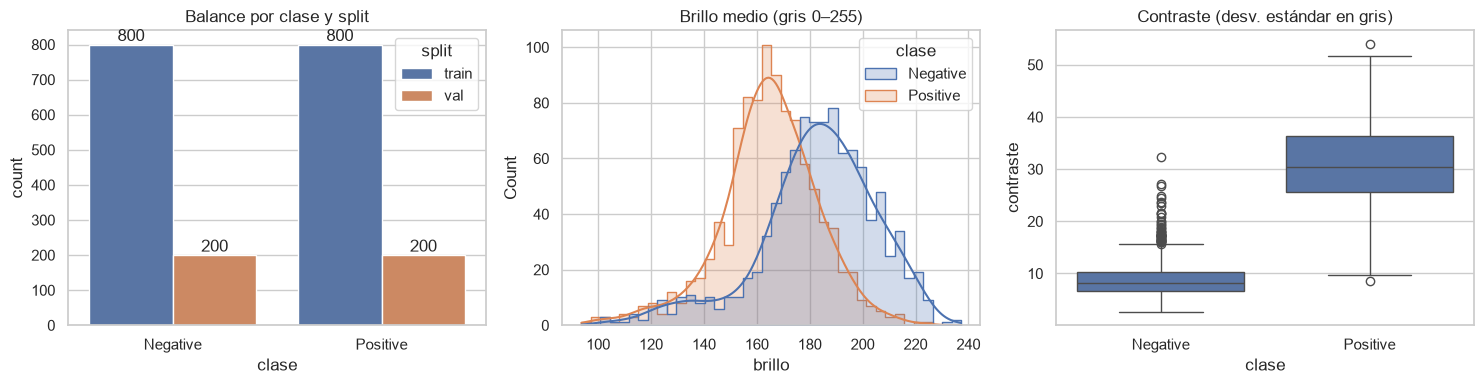

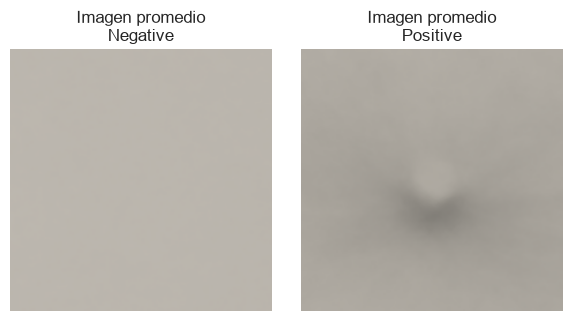

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="clase", hue="split", order=class_names, ax=axes[0])
axes[0].set_title("Balance por clase y split")
for cont in axes[0].containers:
    axes[0].bar_label(cont)

sns.histplot(data=df, x="brillo", hue="clase", hue_order=class_names, bins=40,
             kde=True, element="step", ax=axes[1])
axes[1].set_title("Brillo medio (gris 0–255)")

sns.boxplot(data=df, x="clase", y="contraste", order=class_names, ax=axes[2])
axes[2].set_title("Contraste (desv. estándar en gris)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, cls in zip(axes, class_names):
    paths = df.loc[(df["split"] == "train") & (df["clase"] == cls), "ruta"]
    media = np.mean([np.asarray(Image.open(p).convert("RGB"), dtype=np.float32) for p in paths], axis=0)
    ax.imshow(media.astype(np.uint8))
    ax.set_title(f"Imagen promedio\n{cls}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Muestra visual: 4 imágenes de cada clase

Mosaico 2 × 4 con imágenes **aleatorias** de train (semilla fija para que sea reproducible).
Fila superior: `Negative` (sin grieta). Fila inferior: `Positive` (con grieta).
En cada imagen se indica su brillo y contraste para conectar lo visual con las estadísticas.

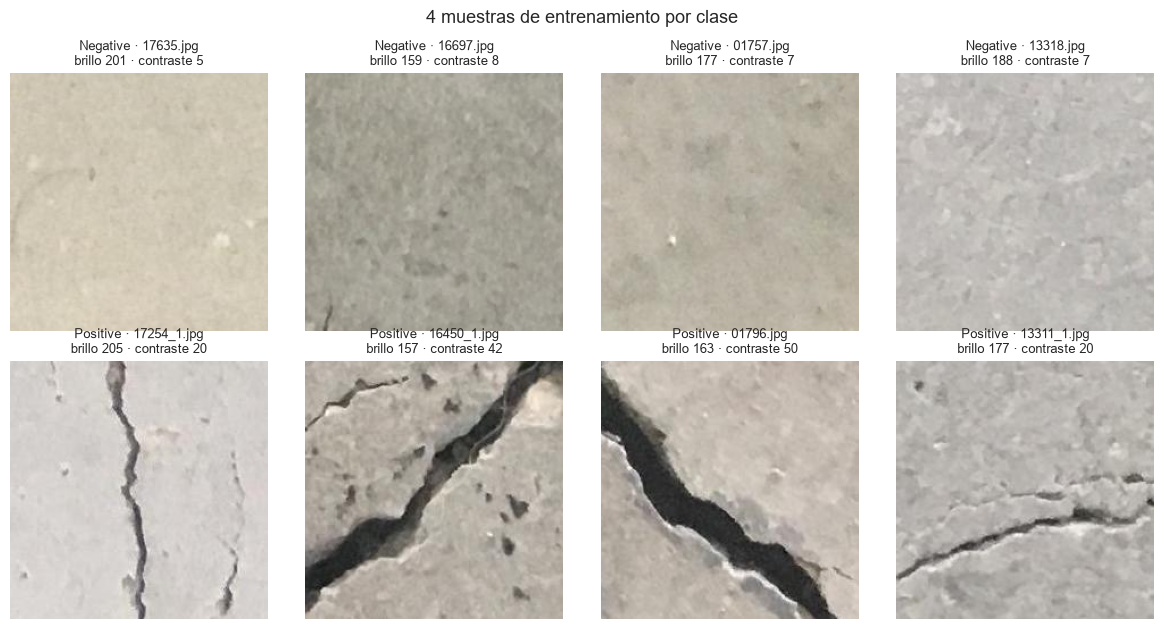

In [6]:
N_EJEMPLOS_MOSAICO = 4

fig, axes = plt.subplots(2, N_EJEMPLOS_MOSAICO, figsize=(3 * N_EJEMPLOS_MOSAICO, 6.4))
for row, cls in enumerate(class_names):
    muestra = df[(df["split"] == "train") & (df["clase"] == cls)].sample(N_EJEMPLOS_MOSAICO, random_state=SEED)
    for col, (_, fila) in enumerate(muestra.iterrows()):
        ax = axes[row, col]
        ax.imshow(Image.open(fila["ruta"]))
        ax.set_title(f"{cls} · {fila['ruta'].name}\nbrillo {fila['brillo']:.0f} · contraste {fila['contraste']:.0f}",
                     fontsize=9)
        ax.axis("off")
plt.suptitle("4 muestras de entrenamiento por clase", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Coherencia del split y duplicados

Comprobamos la proporción train/val y buscamos **imágenes idénticas** comparando el hash MD5 del
contenido del archivo. Comparar solo nombres no sirve: `Negative/00052.jpg` y `Positive/00052.jpg`
son fotos distintas que comparten nombre. Una imagen repetida entre train y val es una
**fuga de datos**: el modelo se evalúa sobre algo que ya vio al entrenar.

In [7]:
import hashlib

total_train = (df["split"] == "train").sum()
total_val = (df["split"] == "val").sum()
print(f"Total train: {total_train} | Total val: {total_val} | Total general: {len(df)}")
print(f"Proporción train/val: {total_train / len(df):.0%} / {total_val / len(df):.0%}")

df["md5"] = df["ruta"].apply(lambda p: hashlib.md5(p.read_bytes()).hexdigest())
dups = df[df.duplicated("md5", keep=False)].sort_values("md5")
dups = dups.assign(archivo=dups["ruta"].map(lambda p: f"{p.parent.parent.name}/{p.parent.name}/{p.name}"))
print(f"\nGrupos de imágenes idénticas: {dups['md5'].nunique()}")
display(dups.groupby("md5")["archivo"].apply(" = ".join).reset_index(drop=True).to_frame("pares idénticos"))
cruzan = dups.groupby("md5")["split"].nunique().gt(1).sum()
print(f"Pares que cruzan train ↔ val (fuga): {cruzan}")

Total train: 1600 | Total val: 400 | Total general: 2000
Proporción train/val: 80% / 20%

Grupos de imágenes idénticas: 5


,pares idénticos
0,train/Positive/15586_1.jpg = val/Positive/1629...
1,train/Negative/10651.jpg = train/Negative/1931...
2,train/Negative/10135.jpg = train/Negative/1324...
3,train/Positive/17688_1.jpg = train/Positive/18...
4,val/Positive/16563_1.jpg = val/Positive/16867_...


Pares que cruzan train ↔ val (fuga): 1


## 7. Conclusiones del EDA

- **Balance perfecto**: 1 000 imágenes por clase (800 train + 200 val), split 80/20. Un modelo que
  siempre prediga la misma clase obtiene un 50 % de accuracy; esa es la línea base a superar.
- **Formato homogéneo**: las 2 000 imágenes son RGB de 227 × 227 px, así que el `Resize` escala todas
  igual y no deforma ninguna.
- **El contraste es la señal más fuerte**: `Positive` tiene un contraste medio de ~31 frente a ~9 en
  `Negative` (más de 3 veces). Se explica por la grieta, una línea oscura y nítida sobre un fondo
  uniforme. Las imágenes `Positive` también pesan más en disco (~6,7 KB frente a ~5,4 KB), porque el
  JPEG comprime peor los bordes.
- **El brillo solapa entre clases**: `Positive` es algo más oscura (~165 frente a ~183), pero los
  histogramas se solapan mucho. El brillo por sí solo no basta para separar las clases, y es bueno
  que no sea un atajo trivial.
- **Casi escala de grises**: las medias de R, G y B son muy parecidas, con un leve tono cálido (R > B).
  El color aporta poca información; la forma y la textura son lo que importa.
- **Imagen promedio**: la de `Negative` es un gris plano. La de `Positive` también sale casi plana,
  porque cada grieta tiene una posición y orientación distinta. La CNN debe aprender un patrón
  *local* e invariante a la posición (justo lo que hacen las convoluciones), no una plantilla fija.
- **Duplicados**: hay 5 pares de imágenes idénticas y 1 cruza train → val (`train/Positive/15586_1.jpg`
  = `val/Positive/16298_1.jpg`). Su impacto es mínimo (1 de 400 en val), pero conviene saberlo.
- **Para el data augmentation**: como las grietas aparecen en cualquier orientación, los flips y
  rotaciones son transformaciones válidas que no cambian la etiqueta.

# Parte 2: Preparación de datos y arquitectura CNN

## 8. Estandarización y DataLoaders

Estandarizamos cada canal con la media y la desviación estándar **calculadas sobre train** en la sección 3
(no con los valores genéricos `0.5` ni con los de ImageNet):

$$x' = \frac{x - \mu_c}{\sigma_c}$$

- Así cada canal queda con media ≈ 0 y desviación ≈ 1, lo que da gradientes de escala parecida y un entrenamiento más estable.
- **Solo se usan estadísticas de train**: calcularlas también con val filtraría información del conjunto de evaluación.
- `train_transform` añade data augmentation (flips, rotación, brillo/contraste). Las grietas aparecen en cualquier orientación, así que estas transformaciones no cambian la etiqueta.
- `val_transform` no tiene aleatoriedad: solo `Resize` + `ToTensor` + `Normalize`.
- Las esquinas que deja vacías la rotación se rellenan con el color medio del dataset (y no con negro), para que tras estandarizar valgan ≈ 0 y no aparezcan bordes oscuros artificiales que parezcan grietas.

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True   # elige el algoritmo de convolución más rápido para este tamaño de entrada

IMAGE_SIZE = 128
AUG_ROTATION = 15
BATCH_SIZE = 32

MEDIA = media_canal.tolist()   # calculadas sobre train en la sección 3
STD = std_canal.tolist()
RELLENO = tuple(int(round(m * 255)) for m in MEDIA)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(AUG_ROTATION, fill=RELLENO),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA, STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA, STD),
])

train_ds = datasets.ImageFolder(RUTA_DATOS / "train", transform=train_transform)
val_ds = datasets.ImageFolder(RUTA_DATOS / "val", transform=val_transform)
assert train_ds.classes == class_names, train_ds.class_to_idx

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"PyTorch {torch.__version__} | dispositivo: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
print(f"Clases: {train_ds.class_to_idx}")
print(f"train: {len(train_ds)} imágenes / {len(train_loader)} batches | "
      f"val: {len(val_ds)} imágenes / {len(val_loader)} batches")
print(f"Normalize → media {np.round(MEDIA, 3)}, std {np.round(STD, 3)}")

PyTorch 2.7.1+cu128 | dispositivo: cpu
Clases: {'Negative': 0, 'Positive': 1}
train: 1600 imágenes / 50 batches | val: 400 imágenes / 13 batches
Normalize → media [0.698 0.678 0.646], std [0.132 0.128 0.127]


In [9]:
train_batch = next(iter(train_loader))
print(f"Batch de entrenamiento: {len(train_batch[0])} imágenes, {len(train_batch[1])} etiquetas")

Batch de entrenamiento: 32 imágenes, 32 etiquetas


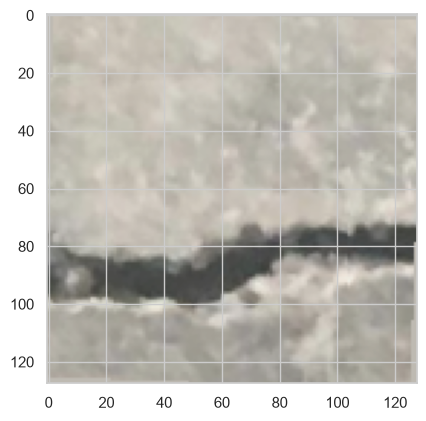

In [10]:
# Mostrar una imagen del train_batch
train_batch = next(iter(train_loader))
img, label = train_batch[0][0], train_batch[1][0]
# Desnormalizar la imagen para mostrarla correctamente
img = img * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEDIA).view(3, 1, 1)
plt.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))

### 8.1 Verificación de la estandarización

Pasamos todo train por `val_transform` (sin augmentation, para medir el efecto de `Normalize` solo) y comprobamos
que cada canal queda con media ≈ 0 y desviación ≈ 1. Luego comparamos el histograma de píxeles antes y después
de estandarizar, y mostramos una imagen `Positive` junto a varias versiones aumentadas.

Tensor train estandarizado: (1600, 3, 128, 128)


,media,std
R,0.0,0.990
G,0.0,0.989
B,0.0,0.989


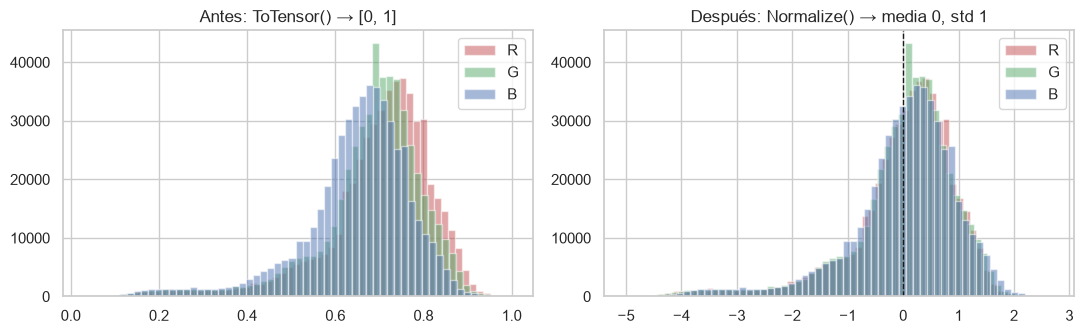

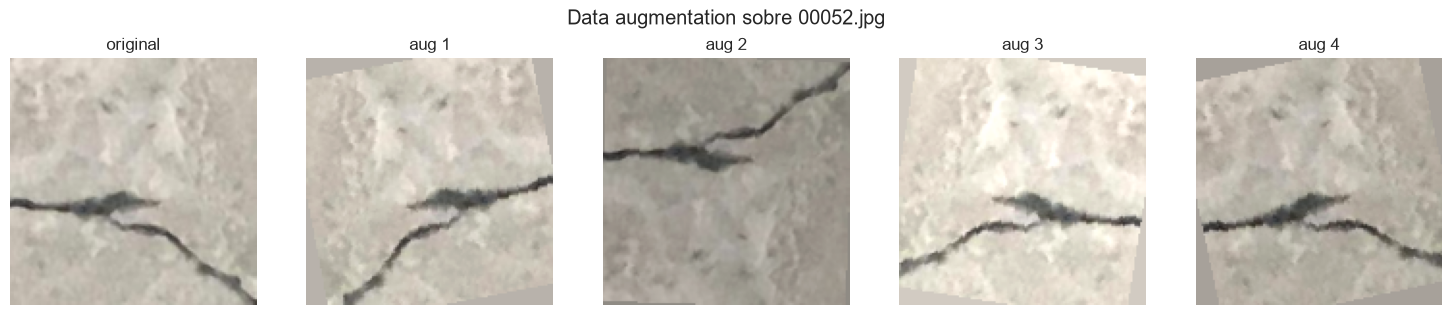

In [11]:
def desnormalizar(t):
    """Tensor estandarizado (C, H, W) → imagen (H, W, C) en [0, 1] para imshow."""
    img = t.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEDIA)
    return img.clip(0, 1)

train_sin_aug = datasets.ImageFolder(RUTA_DATOS / "train", transform=val_transform)
X = torch.cat([x for x, _ in DataLoader(train_sin_aug, batch_size=200)])
print(f"Tensor train estandarizado: {tuple(X.shape)}")
display(pd.DataFrame({"media": X.mean(dim=(0, 2, 3)).numpy(), "std": X.std(dim=(0, 2, 3)).numpy()},
                     index=["R", "G", "B"]).round(3))

X_crudo = X * torch.tensor(STD).view(1, 3, 1, 1) + torch.tensor(MEDIA).view(1, 3, 1, 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for i, canal in enumerate("RGB"):
    axes[0].hist(X_crudo[:, i].flatten()[::50].numpy(), bins=60, alpha=0.5, label=canal, color=canal.lower())
    axes[1].hist(X[:, i].flatten()[::50].numpy(), bins=60, alpha=0.5, label=canal, color=canal.lower())
axes[0].set_title("Antes: ToTensor() → [0, 1]")
axes[1].set_title("Después: Normalize() → media 0, std 1")
axes[1].axvline(0, color="k", ls="--", lw=1)
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

N_AUG_MOSTRADOS = 4
ruta_pos = sorted((RUTA_DATOS / "train" / "Positive").glob("*.jpg"))[0]
img = Image.open(ruta_pos).convert("RGB")
fig, axes = plt.subplots(1, N_AUG_MOSTRADOS + 1, figsize=(3 * (N_AUG_MOSTRADOS + 1), 3.2))
axes[0].imshow(desnormalizar(val_transform(img)))
axes[0].set_title("original")
for i in range(1, N_AUG_MOSTRADOS + 1):
    axes[i].imshow(desnormalizar(train_transform(img)))
    axes[i].set_title(f"aug {i}")
for ax in axes:
    ax.axis("off")
plt.suptitle(f"Data augmentation sobre {ruta_pos.name}")
plt.tight_layout()
plt.show()

## 9. Arquitectura CNN

`CrackCNN` tiene **3 capas convolucionales** y **4 capas fully connected** (50 → 75 → 150 → 2).

**`self.features`**: extrae patrones locales (bordes, líneas oscuras, textura del hormigón).

| Bloque | Capas | Salida (entrada 128×128) | Qué hace |
|--------|-------|--------------------------|----------|
| 1 | `Conv2d(3 → 32, 3×3)` → `ReLU` → `MaxPool2d(2)` | 32 × 64 × 64 | Detecta bordes y cambios de intensidad |
| 2 | `Conv2d(32 → 64, 3×3)` → `ReLU` → `MaxPool2d(2)` | 64 × 32 × 32 | Combina bordes en trazos (segmentos de grieta) |
| 3 | `Conv2d(64 → 128, 3×3)` → `ReLU` → `MaxPool2d(2)` | 128 × 16 × 16 | Patrones más globales: continuidad y forma de la grieta |

**`self.classifier`**: decide *grieta / no grieta*. Primero `AdaptiveAvgPool2d(4×4)` + `Flatten` producen un
vector de 128 · 4 · 4 = 2048 valores, que pasa por las 4 capas FC:

| FC | Capas | Salida |
|----|-------|--------|
| 1 | `Linear(2048 → 50)` → `ReLU` → `Dropout` | 50 |
| 2 | `Linear(50 → 75)` → `ReLU` → `Dropout` | 75 |
| 3 | `Linear(75 → 150)` → `ReLU` → `Dropout` | 150 |
| 4 | `Linear(150 → 2)` | 2 logits (Negative, Positive) |

La última FC no lleva activación: `nn.CrossEntropyLoss` aplica el softmax internamente. Separar `features` de
`classifier` facilita el Grad-CAM, que se engancha a la última `Conv2d` de `self.features`.

In [12]:
N_FILTERS = 32
DROPOUT = 0.3
FC_UNIDADES = [50, 75, 150]   # capas ocultas; la 4.ª FC es la de salida (2 clases)

class CrackCNN(nn.Module):
    def __init__(self, n_filters=N_FILTERS, dropout=DROPOUT, fc_unidades=FC_UNIDADES,
                 n_clases=len(class_names)):
        super().__init__()
        canales = [3, n_filters, n_filters * 2, n_filters * 4]   # 3 → 32 → 64 → 128
        bloques = []
        for c_in, c_out in zip(canales[:-1], canales[1:]):
            bloques += [nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)]
        self.features = nn.Sequential(*bloques)

        capas_fc = [nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten()]
        n_in = canales[-1] * 4 * 4
        for n_out in fc_unidades:
            capas_fc += [nn.Linear(n_in, n_out), nn.ReLU(), nn.Dropout(dropout)]
            n_in = n_out
        capas_fc.append(nn.Linear(n_in, n_clases))
        self.classifier = nn.Sequential(*capas_fc)

    def forward(self, x):
        return self.classifier(self.features(x))


torch.manual_seed(SEED)
modelo = CrackCNN().to(device)
print(modelo)

CrackCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=2048, out_features=50, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=50, out_features=75, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=75, out_features=150, bias=True)
    (9): ReLU()
    (10):

### 9.1 Resumen capa a capa

Pasamos un batch real de `train_loader` por el modelo y registramos con *hooks* la forma de salida y el
número de parámetros de cada capa. Así se ve cómo la resolución espacial baja (128 → 64 → 32 → 16 → 4) mientras
el número de canales sube (3 → 32 → 64 → 128).

In [13]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)

resumen, hooks = [], []
for nombre, capa in modelo.named_modules():
    if len(list(capa.children())) == 0:   # solo capas "hoja"
        def hook(m, inp, out, nombre=nombre):
            resumen.append({
                "capa": nombre,
                "tipo": type(m).__name__,
                "salida": str(tuple(out.shape[1:])),
                "parámetros": sum(p.numel() for p in m.parameters()),
            })
        hooks.append(capa.register_forward_hook(hook))

modelo.eval()
with torch.no_grad():
    logits = modelo(xb)
for h in hooks:
    h.remove()

tabla = pd.DataFrame(resumen)
display(pd.concat([pd.DataFrame([{"capa": "entrada", "tipo": "", "salida": str(tuple(xb.shape[1:])),
                                  "parámetros": 0}]), tabla], ignore_index=True))

n_total = sum(p.numel() for p in modelo.parameters())
n_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Parámetros totales: {n_total:,} | entrenables: {n_entrenables:,} "
      f"(~{n_total * 4 / 1024:.0f} KB en float32)")
print(f"Batch de entrada: {tuple(xb.shape)} → logits: {tuple(logits.shape)}")
print(f"Probabilidades (sin entrenar) de las 3 primeras imágenes:\n{torch.softmax(logits[:3], dim=1).cpu().numpy().round(3)}")

,capa,tipo,salida,parámetros
0,entrada,,"(3, 128, 128)",0
1,features.0,Conv2d,"(32, 128, 128)",896
2,features.1,ReLU,"(32, 128, 128)",0
3,features.2,MaxPool2d,"(32, 64, 64)",0
4,features.3,Conv2d,"(64, 64, 64)",18496
5,features.4,ReLU,"(64, 64, 64)",0
6,features.5,MaxPool2d,"(64, 32, 32)",0
7,features.6,Conv2d,"(128, 32, 32)",73856
8,features.7,ReLU,"(128, 32, 32)",0
9,features.8,MaxPool2d,"(128, 16, 16)",0


Parámetros totales: 211,225 | entrenables: 211,225 (~825 KB en float32)
Batch de entrada: (32, 3, 128, 128) → logits: (32, 2)
Probabilidades (sin entrenar) de las 3 primeras imágenes:
[[0.507 0.493]
 [0.506 0.494]
 [0.507 0.493]]


# Parte 3: Entrenamiento

## 10. Conjunto de test

El dataset solo trae `train/` y `val/`. Para tener un conjunto de **test** independiente dividimos `val/` en dos
mitades estratificadas por clase (misma proporción Negative/Positive en cada una):

- **train** (1 600): ajusta los pesos.
- **val** (~200): decide cuál es la mejor época (selección del modelo).
- **test** (~200): estimación final del rendimiento. Lo evaluamos en cada época solo para dibujar su curva,
  **nunca** para tomar decisiones de entrenamiento.

Antes de dividir quitamos de val/test las imágenes cuyo contenido (hash MD5) ya aparece en train, y los duplicados
internos de val. Así eliminamos la fuga de datos detectada en la sección 6.

In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

md5_train = set(df.loc[df["split"] == "train", "md5"])
vistos, idx_limpios, descartadas = set(), [], []
for i, (ruta, _) in enumerate(val_ds.samples):
    h = hashlib.md5(Path(ruta).read_bytes()).hexdigest()
    if h in md5_train or h in vistos:
        descartadas.append(Path(ruta).name)
        continue
    vistos.add(h)
    idx_limpios.append(i)
print(f"Descartadas de val por duplicado/fuga: {descartadas}")

etiquetas = [val_ds.targets[i] for i in idx_limpios]
idx_val, idx_test = train_test_split(idx_limpios, test_size=0.5, stratify=etiquetas, random_state=SEED)
val_split = Subset(val_ds, idx_val)
test_ds = Subset(val_ds, idx_test)

val_loader = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def conteo_por_clase(targets):
    return pd.Series(targets).map(dict(enumerate(class_names))).value_counts().reindex(class_names)

display(pd.DataFrame({
    "train": conteo_por_clase(train_ds.targets),
    "val": conteo_por_clase([val_ds.targets[i] for i in idx_val]),
    "test": conteo_por_clase([val_ds.targets[i] for i in idx_test]),
}).T.assign(total=lambda t: t.sum(axis=1)))

Descartadas de val por duplicado/fuga: ['16298_1.jpg', '16867_1.jpg']


,Negative,Positive,total
train,800,800,1600
val,100,99,199
test,100,99,199


## 11. Funciones de entrenamiento y evaluación

- `train_one_epoch`: modo `train()` (Dropout activo) y una pasada completa por el loader. Para cada batch calcula la
  pérdida, hace backpropagation y actualiza los pesos.
- `eval_epoch`: modo `eval()` (Dropout apagado) y sin gradientes. Solo mide la pérdida y la accuracy.

Ambas muestran una barra de progreso por batch con `tqdm` y devuelven la pérdida y la accuracy medias de la época.

In [15]:
from tqdm.auto import tqdm

def train_one_epoch(modelo, loader, criterion, optimizer, desc="train"):
    modelo.train()
    loss_total, aciertos, n = 0.0, 0, 0
    for xb, yb in tqdm(loader, desc=desc, leave=False, unit="batch"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = modelo(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item() * len(yb)
        aciertos += (logits.argmax(dim=1) == yb).sum().item()
        n += len(yb)
    return loss_total / n, aciertos / n


@torch.no_grad()
def eval_epoch(modelo, loader, criterion, desc="eval"):
    modelo.eval()
    loss_total, aciertos, n = 0.0, 0, 0
    for xb, yb in tqdm(loader, desc=desc, leave=False, unit="batch"):
        xb, yb = xb.to(device), yb.to(device)
        logits = modelo(xb)
        loss_total += criterion(logits, yb).item() * len(yb)
        aciertos += (logits.argmax(dim=1) == yb).sum().item()
        n += len(yb)
    return loss_total / n, aciertos / n

## 12. Entrenamiento (50 épocas)

- Optimizador **Adam** con `lr = 1e-3` y pérdida **CrossEntropyLoss**.
- Se reinicia el modelo con la semilla fija, así el entrenamiento es reproducible aunque se vuelva a ejecutar la celda.
- **Barra de progreso** principal por época, con barras anidadas por batch. La barra principal muestra las métricas
  de la última época y cada 5 épocas se imprime una línea de resumen.
- Guardamos en memoria los pesos de la época con **menor pérdida de validación**. Al terminar se restauran esos
  pesos, porque con 50 épocas es probable que el modelo empiece a sobreajustar antes del final.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Dispositivo: cpu


In [16]:
import copy
import time

N_EPOCHS = 10
LEARNING_RATE = 1e-3

torch.manual_seed(SEED)
modelo = CrackCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

history = {f"{s}_{m}": [] for s in ("train", "val", "test") for m in ("loss", "acc")}
mejor = {"val_loss": float("inf"), "epoch": 0, "pesos": None}

inicio = time.time()
barra = tqdm(range(1, N_EPOCHS + 1), desc="Entrenamiento", unit="época")
for epoch in barra:
    tr_loss, tr_acc = train_one_epoch(modelo, train_loader, criterion, optimizer, desc=f"época {epoch} · train")
    va_loss, va_acc = eval_epoch(modelo, val_loader, criterion, desc="val")
    te_loss, te_acc = eval_epoch(modelo, test_loader, criterion, desc="test")

    for clave, valor in zip(history, (tr_loss, tr_acc, va_loss, va_acc, te_loss, te_acc)):
        history[clave].append(valor)

    if va_loss < mejor["val_loss"]:
        mejor = {"val_loss": va_loss, "epoch": epoch, "pesos": copy.deepcopy(modelo.state_dict())}

    barra.set_postfix(train_loss=f"{tr_loss:.3f}", val_loss=f"{va_loss:.3f}", val_acc=f"{va_acc:.3f}")
    if epoch == 1 or epoch % 5 == 0:
        tqdm.write(f"Época {epoch:2d}/{N_EPOCHS} | loss train {tr_loss:.4f} · val {va_loss:.4f} · test {te_loss:.4f} "
                   f"| acc train {tr_acc:.3f} · val {va_acc:.3f} · test {te_acc:.3f}")

modelo.load_state_dict(mejor["pesos"])
print(f"\n✅ Entrenamiento completado en {(time.time() - inicio) / 60:.1f} min.")
print(f"Mejor época según val: {mejor['epoch']} (val_loss = {mejor['val_loss']:.4f}); pesos restaurados.")

Entrenamiento:   0%|          | 0/10 [00:00<?, ?época/s]

época 1 · train:   0%|          | 0/50 [00:00<?, ?batch/s]

val:   0%|          | 0/7 [00:00<?, ?batch/s]

test:   0%|          | 0/7 [00:00<?, ?batch/s]

Época  1/10 | loss train 0.4671 · val 0.1201 · test 0.1407 | acc train 0.797 · val 0.975 · test 0.975


...

test:   0%|          | 0/7 [00:00<?, ?batch/s]

época 10 · train:   0%|          | 0/50 [00:00<?, ?batch/s]

val:   0%|          | 0/7 [00:00<?, ?batch/s]

test:   0%|          | 0/7 [00:00<?, ?batch/s]

Época 10/10 | loss train 0.0450 · val 0.0466 · test 0.0500 | acc train 0.989 · val 0.975 · test 0.975

✅ Entrenamiento completado en 2.0 min.
Mejor época según val: 8 (val_loss = 0.0116); pesos restaurados.


## 13. Curvas de pérdida y accuracy: train, val y test

La línea vertical discontinua marca la mejor época según val (los pesos que conserva el modelo).
- Si **train** sigue bajando mientras **val/test** se estancan o suben, el modelo está **sobreajustando**.
- Si **val** y **test** van juntas, el conjunto de validación es representativo y la selección de la mejor época generaliza.

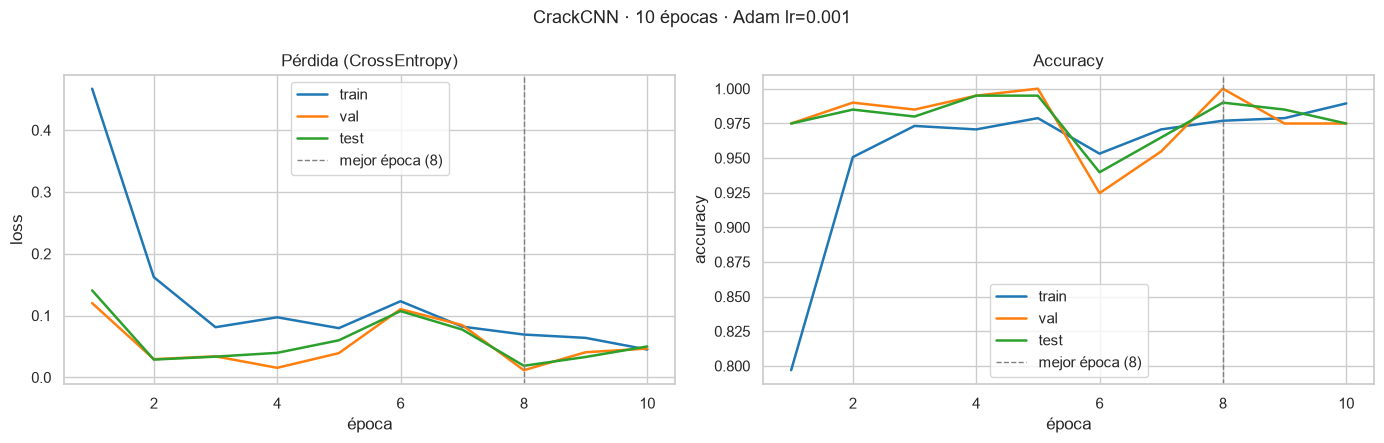

train:   0%|          | 0/50 [00:00<?, ?batch/s]

val:   0%|          | 0/7 [00:00<?, ?batch/s]

test:   0%|          | 0/7 [00:00<?, ?batch/s]

Modelo final (época 8), train evaluado sin augmentation:


,loss,accuracy
train,0.0358,0.9906
val,0.0116,1.0000
test,0.0187,0.9899


In [17]:
epocas = range(1, N_EPOCHS + 1)
colores = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
for s, color in colores.items():
    ax1.plot(epocas, history[f"{s}_loss"], label=s, color=color, lw=1.8)
    ax2.plot(epocas, history[f"{s}_acc"], label=s, color=color, lw=1.8)
for ax in (ax1, ax2):
    ax.axvline(mejor["epoch"], color="gray", ls="--", lw=1, label=f"mejor época ({mejor['epoch']})")
    ax.set_xlabel("época")
    ax.legend()
ax1.set_title("Pérdida (CrossEntropy)")
ax1.set_ylabel("loss")
ax2.set_title("Accuracy")
ax2.set_ylabel("accuracy")
plt.suptitle(f"CrackCNN · {N_EPOCHS} épocas · Adam lr={LEARNING_RATE}", fontsize=13)
plt.tight_layout()
plt.show()

# Métricas con los pesos restaurados (mejor época según val)
resumen_final = pd.DataFrame(
    {s: eval_epoch(modelo, loader, criterion, desc=s)
     for s, loader in (("train", DataLoader(train_sin_aug, batch_size=BATCH_SIZE)),
                       ("val", val_loader), ("test", test_loader))},
    index=["loss", "accuracy"]).T.round(4)
print(f"Modelo final (época {mejor['epoch']}), train evaluado sin augmentation:")
display(resumen_final)

In [19]:
# Guardar el modelo entrenado
torch.save(modelo.state_dict(), "crackcnn.pth")

In [20]:
modelo_2 = CrackCNN().to(device)
modelo_2.load_state_dict(torch.load("crackcnn.pth"))

<All keys matched successfully>

In [21]:
modelo_2

CrackCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=2048, out_features=50, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=50, out_features=75, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=75, out_features=150, bias=True)
    (9): ReLU()
    (10):